In [ ]:
import torchvision.datasets as dsets
import torchvision.transforms as transforms

In [ ]:
train_dataset = dsets.MNIST(
    root="./data", train=True, transform=transforms.ToTensor(), download=True
)
test_dataset = dsets.MNIST(
    root="./data", train=False, transform=transforms.ToTensor(), download=True
)

In [ ]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [ ]:
import matplotlib.pyplot as plt

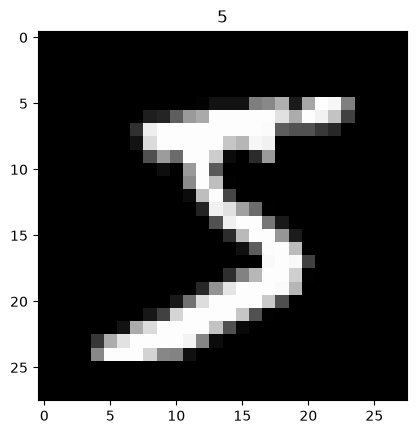

In [ ]:
plt.imshow(train_dataset.data[0].numpy(), cmap="gray")
plt.title("%d" % train_dataset.targets[0])
plt.show()

In [ ]:
input_size = 28 * 28
hidden_size = 500
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

In [ ]:
import torch.utils.data as Data

In [ ]:
train_loader = Data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True
)

test_loader = Data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False
)

In [ ]:
import torch.nn as nn

In [ ]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [ ]:
model = Model(input_size, hidden_size, num_classes)

In [ ]:
import torch.optim as optim

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
from torch.autograd import Variable

In [ ]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = Variable(images.view(-1, 28 * 28))
        labels = Variable(labels)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print("Epoch: %d, Batch: %d, Loss: %.4f" % (epoch + 1, i + 1, loss.item()))

Epoch: 1, Batch: 100, Loss: 0.2944
Epoch: 1, Batch: 200, Loss: 0.2483
Epoch: 1, Batch: 300, Loss: 0.3383
Epoch: 1, Batch: 400, Loss: 0.2213
Epoch: 1, Batch: 500, Loss: 0.2061
Epoch: 1, Batch: 600, Loss: 0.1932
Epoch: 2, Batch: 100, Loss: 0.2397
Epoch: 2, Batch: 200, Loss: 0.0867
Epoch: 2, Batch: 300, Loss: 0.1135
Epoch: 2, Batch: 400, Loss: 0.0897
Epoch: 2, Batch: 500, Loss: 0.0523
Epoch: 2, Batch: 600, Loss: 0.0429
Epoch: 3, Batch: 100, Loss: 0.1350
Epoch: 3, Batch: 200, Loss: 0.1253
Epoch: 3, Batch: 300, Loss: 0.1063
Epoch: 3, Batch: 400, Loss: 0.0700
Epoch: 3, Batch: 500, Loss: 0.1054
Epoch: 3, Batch: 600, Loss: 0.0218
Epoch: 4, Batch: 100, Loss: 0.1004
Epoch: 4, Batch: 200, Loss: 0.0213
Epoch: 4, Batch: 300, Loss: 0.0113
Epoch: 4, Batch: 400, Loss: 0.0281
Epoch: 4, Batch: 500, Loss: 0.0685
Epoch: 4, Batch: 600, Loss: 0.0448
Epoch: 5, Batch: 100, Loss: 0.0318
Epoch: 5, Batch: 200, Loss: 0.0411
Epoch: 5, Batch: 300, Loss: 0.0382
Epoch: 5, Batch: 400, Loss: 0.0530
Epoch: 5, Batch: 500

In [ ]:
import torch

In [ ]:
correct = 0
total = 0
for images, labels in test_loader:
    images = Variable(images.view(-1, 28 * 28))
    outputs = model(images)
    _, pred = torch.max(outputs.data, 1)
    correct += (pred == labels).sum()
    total += labels.size(0)
print("Accuracy: %.3f %%" % (100.0 * float(correct) / float(total)))

Accuracy: 97.860 %


In [ ]:
for images, labels in test_loader:
    print(images.shape)
    break

torch.Size([100, 1, 28, 28])


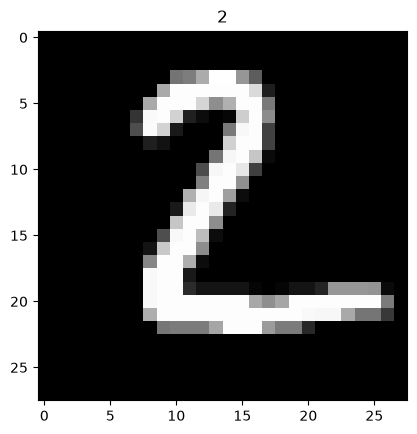

tensor([[ -4.1204,  -7.8561,  -2.9285,  -1.2412, -12.3850,  -5.5781, -15.8505,
          10.1617,  -3.7967,  -2.1268],
        [ -5.1593,   0.7203,   9.1656,  -0.9276, -18.8070,  -5.2350,  -5.1879,
         -15.5373,  -0.3787, -15.6810]], grad_fn=<AddmmBackward0>)
tensor([7, 2])


In [ ]:
plt.imshow(images[1][0], cmap="gray")
plt.title(labels[1].item())
plt.show()

images_flat = Variable(images[:2].view(-1, 28 * 28))
outputs = model(images_flat)
print(outputs)

_, pred_y = torch.max(outputs.data, -1)
print(pred_y)

In [ ]:
torch.save(model.state_dict(), "model.pkl")

In [ ]:
model2 = Model(input_size, hidden_size, num_classes)
model2.load_state_dict(torch.load("model.pkl"))

<All keys matched successfully>

In [ ]:
correct = 0
total = 0
for images, labels in test_loader:
    images = Variable(images.view(-1, 28 * 28))
    outputs = model2(images)
    _, pred = torch.max(outputs.data, 1)
    correct += (pred == labels).sum()
    total += labels.size(0)
print("Accuracy: %.3f %%" % (100.0 * float(correct) / float(total)))

Accuracy: 97.860 %


In [ ]:
torch.save(model2, "model2.pkl")

In [ ]:
model3 = torch.load("model2.pkl", weights_only=False)

In [ ]:
correct = 0
total = 0
for images, labels in test_loader:
    images = Variable(images.view(-1, 28 * 28))
    outputs = model3(images)
    _, pred = torch.max(outputs.data, 1)
    correct += (pred == labels).sum()
    total += labels.size(0)
print("Accuracy: %.3f %%" % (100.0 * float(correct) / float(total)))

Accuracy: 97.860 %


In [ ]:
model4 = nn.Sequential(
    nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, num_classes)
)
print(model)
print(model4)

Model(
  (fc1): Linear(in_features=784, out_features=500, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)
Sequential(
  (0): Linear(in_features=784, out_features=500, bias=True)
  (1): ReLU()
  (2): Linear(in_features=500, out_features=10, bias=True)
)


In [ ]:
# optimizer = optim.SGD(model4.parameters(), lr=learning_rate, momentum=0.5)
# optimizer = optim.Adagrad(model4.parameters(), lr=learning_rate)
# optimizer = optim.RMSprop(model4.parameters(), lr=learning_rate)
optimizer = optim.Adam(model4.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = Variable(images.view(-1, 28 * 28))
        labels = Variable(labels)

        outputs = model4(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print("Epoch: %d, Batch: %d, Loss: %.4f" % (epoch + 1, i + 1, loss.item()))

Epoch: 1, Batch: 100, Loss: 0.0328
Epoch: 1, Batch: 200, Loss: 0.0102
Epoch: 1, Batch: 300, Loss: 0.0459
Epoch: 1, Batch: 400, Loss: 0.0213
Epoch: 1, Batch: 500, Loss: 0.0481
Epoch: 1, Batch: 600, Loss: 0.0162
Epoch: 2, Batch: 100, Loss: 0.0250
Epoch: 2, Batch: 200, Loss: 0.0041
Epoch: 2, Batch: 300, Loss: 0.0114
Epoch: 2, Batch: 400, Loss: 0.0211
Epoch: 2, Batch: 500, Loss: 0.0194
Epoch: 2, Batch: 600, Loss: 0.0167
Epoch: 3, Batch: 100, Loss: 0.0064
Epoch: 3, Batch: 200, Loss: 0.0070
Epoch: 3, Batch: 300, Loss: 0.0080
Epoch: 3, Batch: 400, Loss: 0.0256
Epoch: 3, Batch: 500, Loss: 0.0178
Epoch: 3, Batch: 600, Loss: 0.0308
Epoch: 4, Batch: 100, Loss: 0.0233
Epoch: 4, Batch: 200, Loss: 0.1185
Epoch: 4, Batch: 300, Loss: 0.0570
Epoch: 4, Batch: 400, Loss: 0.0291
Epoch: 4, Batch: 500, Loss: 0.0119
Epoch: 4, Batch: 600, Loss: 0.0317
Epoch: 5, Batch: 100, Loss: 0.0298
Epoch: 5, Batch: 200, Loss: 0.0057
Epoch: 5, Batch: 300, Loss: 0.0097
Epoch: 5, Batch: 400, Loss: 0.0141
Epoch: 5, Batch: 500